# Tasks 7 & 8: Virtual Trading & Performance Tracking
**Task 7:** Execute trades on StockGro and record entry/exit prices.
**Task 8:** Compare model predictions vs actual market prices. Compute portfolio return.

In [1]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle, warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

STOCKS = {
    'RELIANCE.NS'   : 'Reliance',
    'HDFCBANK.NS'   : 'HDFC Bank',
    'INFY.NS'       : 'Infosys',
    'SUNPHARMA.NS'  : 'Sun Pharma',
    'MARUTI.NS'     : 'Maruti',
    'HINDUNILVR.NS' : 'HUL',
    'TATASTEEL.NS'  : 'Tata Steel',
}
TOTAL_CAPITAL = 1_000_000
print('Imports ready')

Imports ready


In [2]:
# ── LOAD PORTFOLIO & FORECASTS ───────────────────────────────────────────────
portfolio = pd.read_csv('results/05_portfolio_allocation.csv')
print('Portfolio allocation:')
print(portfolio[['Stock', 'Symbol', 'Shares', 'Last Price (\u20b9)', 'Deployed (\u20b9)']].to_string(index=False))

with open('data/arima_forecasts.pkl', 'rb') as f:
    arima_forecasts = pickle.load(f)
with open('data/prophet_forecasts.pkl', 'rb') as f:
    prophet_forecasts = pickle.load(f)

print('\nForecasts loaded.')

Portfolio allocation:
     Stock        Symbol  Shares  Last Price (₹)  Deployed (₹)
       HUL HINDUNILVR.NS     130          2290.2      297726.0
 HDFC Bank   HDFCBANK.NS     221           990.9      218989.0
Sun Pharma  SUNPHARMA.NS     120          1709.1      205092.0
  Reliance   RELIANCE.NS      60          1539.8       92388.0
    Maruti     MARUTI.NS       4         16647.0       66588.0
   Infosys       INFY.NS      35          1621.6       56756.0
Tata Steel  TATASTEEL.NS     284           175.8       49927.0

Forecasts loaded.


## Step 1: Actual Prices from StockGro
Day 1 = 11 May 2026 closing (3:26 PM IST) | Day 2 = 12 May 2026 closing (3:23 PM IST)

In [3]:
# ── ACTUAL PRICES & SHARES FROM STOCKGRO ─────────────────────────────────────

TRADE_DAY1 = '2026-05-11'
TRADE_DAY2 = '2026-05-12'

actual_prices = {
    'RELIANCE.NS'   : {'day1': 1365.92, 'day2': 1348.35},
    'HDFCBANK.NS'   : {'day1': 752.41,  'day2': 740.45},
    'INFY.NS'       : {'day1': 1159.58, 'day2': 1125.90},
    'SUNPHARMA.NS'  : {'day1': 1858.73, 'day2': 1829.99},
    'MARUTI.NS'     : {'day1': 13262.17,'day2': 12896.89},
    'HINDUNILVR.NS' : {'day1': 2287.66, 'day2': 2221.93},
    'TATASTEEL.NS'  : {'day1': 209.44,  'day2': 209.63},
}

actual_shares = {
    'RELIANCE.NS'   : 67,
    'HDFCBANK.NS'   : 289,
    'INFY.NS'       : 49,
    'SUNPHARMA.NS'  : 110,
    'MARUTI.NS'     : 5,
    'HINDUNILVR.NS' : 131,
    'TATASTEEL.NS'  : 237,
}

print(f'Trade Day 1 : {TRADE_DAY1}')
print(f'Trade Day 2 : {TRADE_DAY2}')
print('\nActual closing prices loaded.')

Trade Day 1 : 2026-05-11
Trade Day 2 : 2026-05-12

Actual closing prices loaded.


## Step 2: Extract Model Predictions for Trade Days

In [4]:
# ── GET PREDICTED PRICES FOR TRADE DAYS ──────────────────────────────────────
predictions = {}

for sym, name in STOCKS.items():
    arima_fc   = arima_forecasts.get(sym, {})
    prophet_fc = prophet_forecasts.get(sym, pd.DataFrame())

    arima_vals = arima_fc.get('forecast', pd.Series(dtype=float))

    if not prophet_fc.empty and 'ds' in prophet_fc.columns:
        p1 = prophet_fc[prophet_fc['ds'].astype(str).str[:10] == TRADE_DAY1]['yhat'].values
        p2 = prophet_fc[prophet_fc['ds'].astype(str).str[:10] == TRADE_DAY2]['yhat'].values
    else:
        p1, p2 = [], []

    pred_d1_arima   = float(arima_vals.iloc[0]) if len(arima_vals) > 0 else None
    pred_d2_arima   = float(arima_vals.iloc[1]) if len(arima_vals) > 1 else None
    pred_d1_prophet = float(p1[0]) if len(p1) > 0 else None
    pred_d2_prophet = float(p2[0]) if len(p2) > 0 else None

    ens1_vals = [v for v in [pred_d1_arima, pred_d1_prophet] if v is not None]
    ens2_vals = [v for v in [pred_d2_arima, pred_d2_prophet] if v is not None]

    predictions[sym] = {
        'name'              : name,
        'pred_day1_arima'   : pred_d1_arima,
        'pred_day2_arima'   : pred_d2_arima,
        'pred_day1_prophet' : pred_d1_prophet,
        'pred_day2_prophet' : pred_d2_prophet,
        'pred_day1_ensemble': float(np.mean(ens1_vals)) if ens1_vals else None,
        'pred_day2_ensemble': float(np.mean(ens2_vals)) if ens2_vals else None,
    }

print('Predictions extracted.')
for sym, p in predictions.items():
    print(f"  {p['name']:12s}  D1_ens={p['pred_day1_ensemble']}  D2_ens={p['pred_day2_ensemble']}")

Predictions extracted.
  Reliance      D1_ens=1539.265552676146  D2_ens=1539.6802629993977
  HDFC Bank     D1_ens=991.033148273673  D2_ens=990.5895069261234
  Infosys       D1_ens=1621.5999755859375  D2_ens=1621.5999755859375
  Sun Pharma    D1_ens=1709.1799129212748  D2_ens=1708.9076679260322
  Maruti        D1_ens=16658.920097506467  D2_ens=16657.01564877236
  HUL           D1_ens=2289.908849694794  D2_ens=2290.030603903337
  Tata Steel    D1_ens=175.8000030517578  D2_ens=175.8000030517578


## Step 3: Predicted vs Actual Comparison

In [5]:
# ── PREDICTION vs ACTUAL TABLE ───────────────────────────────────────────────
rows = []
for sym, name in STOCKS.items():
    p   = predictions[sym]
    act = actual_prices[sym]

    pred_d1 = p['pred_day1_ensemble']
    pred_d2 = p['pred_day2_ensemble']
    act_d1  = act['day1']
    act_d2  = act['day2']

    mape_d1 = round(abs(act_d1 - pred_d1) / act_d1 * 100, 2) if pred_d1 else None
    mape_d2 = round(abs(act_d2 - pred_d2) / act_d2 * 100, 2) if pred_d2 else None

    dir_pred    = 'UP' if (pred_d2 and pred_d1 and pred_d2 > pred_d1) else 'DOWN'
    dir_act     = 'UP' if act_d2 > act_d1 else 'DOWN'
    dir_correct = dir_pred == dir_act

    rows.append({
        'Stock'           : name,
        'Pred D1 (Rs)'    : round(pred_d1, 1) if pred_d1 else 'N/A',
        'Actual D1 (Rs)'  : act_d1,
        'MAPE D1 (%)'     : mape_d1,
        'Pred D2 (Rs)'    : round(pred_d2, 1) if pred_d2 else 'N/A',
        'Actual D2 (Rs)'  : act_d2,
        'MAPE D2 (%)'     : mape_d2,
        'Dir Predicted'   : dir_pred,
        'Dir Actual'      : dir_act,
        'Dir Correct'     : 'YES' if dir_correct else 'NO',
    })

df_compare = pd.DataFrame(rows)
print(df_compare.to_string(index=False))
df_compare.to_csv('results/08_prediction_vs_actual.csv', index=False)

valid = df_compare[df_compare['MAPE D1 (%)'].notna()]
if len(valid):
    avg_mape = pd.to_numeric(valid['MAPE D1 (%)'], errors='coerce').mean()
    dir_acc  = (df_compare['Dir Correct'] == 'YES').mean() * 100
    print(f'\nAvg MAPE (Day 1) : {avg_mape:.2f}%')
    print(f'Directional Acc  : {dir_acc:.1f}%')

     Stock  Pred D1 (Rs)  Actual D1 (Rs)  MAPE D1 (%)  Pred D2 (Rs)  Actual D2 (Rs)  MAPE D2 (%) Dir Predicted Dir Actual Dir Correct
  Reliance        1539.3         1365.92        12.69        1539.7         1348.35        14.19            UP       DOWN          NO
 HDFC Bank         991.0          752.41        31.71         990.6          740.45        33.78          DOWN       DOWN         YES
   Infosys        1621.6         1159.58        39.84        1621.6         1125.90        44.03          DOWN       DOWN         YES
Sun Pharma        1709.2         1858.73         8.05        1708.9         1829.99         6.62          DOWN       DOWN         YES
    Maruti       16658.9        13262.17        25.61       16657.0        12896.89        29.16          DOWN       DOWN         YES
       HUL        2289.9         2287.66         0.10        2290.0         2221.93         3.06            UP       DOWN          NO
Tata Steel         175.8          209.44        16.06         

## Step 4: Portfolio Return Analysis

In [6]:
# ── PORTFOLIO RETURN ─────────────────────────────────────────────────────────
total_invested = 0
total_value_d2 = 0
returns = []

for sym, name in STOCKS.items():
    act    = actual_prices[sym]
    shares = actual_shares[sym]

    buy_price  = act['day1']
    sell_price = act['day2']
    invested   = shares * buy_price
    value_d2   = shares * sell_price
    ret_pct    = (sell_price - buy_price) / buy_price * 100
    pnl        = value_d2 - invested

    total_invested += invested
    total_value_d2 += value_d2

    returns.append({
        'Stock'        : name,
        'Shares'       : shares,
        'Buy D1 (Rs)'  : round(buy_price, 2),
        'Close D2 (Rs)': round(sell_price, 2),
        'Invested (Rs)': round(invested),
        'Value D2 (Rs)': round(value_d2),
        'P&L (Rs)'     : round(pnl),
        'Return (%)'   : round(ret_pct, 2),
    })

df_returns = pd.DataFrame(returns)
print(df_returns.to_string(index=False))

portfolio_return = (total_value_d2 - total_invested) / total_invested * 100
total_pnl = total_value_d2 - total_invested

print(f'\nTotal Invested  : Rs {total_invested:,.0f}')
print(f'Total Value D2  : Rs {total_value_d2:,.0f}')
print(f'Total P&L       : Rs {total_pnl:+,.0f}')
print(f'Portfolio Return: {portfolio_return:+.2f}%')

df_returns.to_csv('results/08_portfolio_return.csv', index=False)

     Stock  Shares  Buy D1 (Rs)  Close D2 (Rs)  Invested (Rs)  Value D2 (Rs)  P&L (Rs)  Return (%)
  Reliance      67      1365.92        1348.35          91517          90339     -1177       -1.29
 HDFC Bank     289       752.41         740.45         217446         213990     -3456       -1.59
   Infosys      49      1159.58        1125.90          56819          55169     -1650       -2.90
Sun Pharma     110      1858.73        1829.99         204460         201299     -3161       -1.55
    Maruti       5     13262.17       12896.89          66311          64484     -1826       -2.75
       HUL     131      2287.66        2221.93         299683         291073     -8611       -2.87
Tata Steel     237       209.44         209.63          49637          49682        45        0.09

Total Invested  : Rs 985,874
Total Value D2  : Rs 966,037
Total P&L       : Rs -19,837
Portfolio Return: -2.01%


## Step 5: Visualise Predicted vs Actual

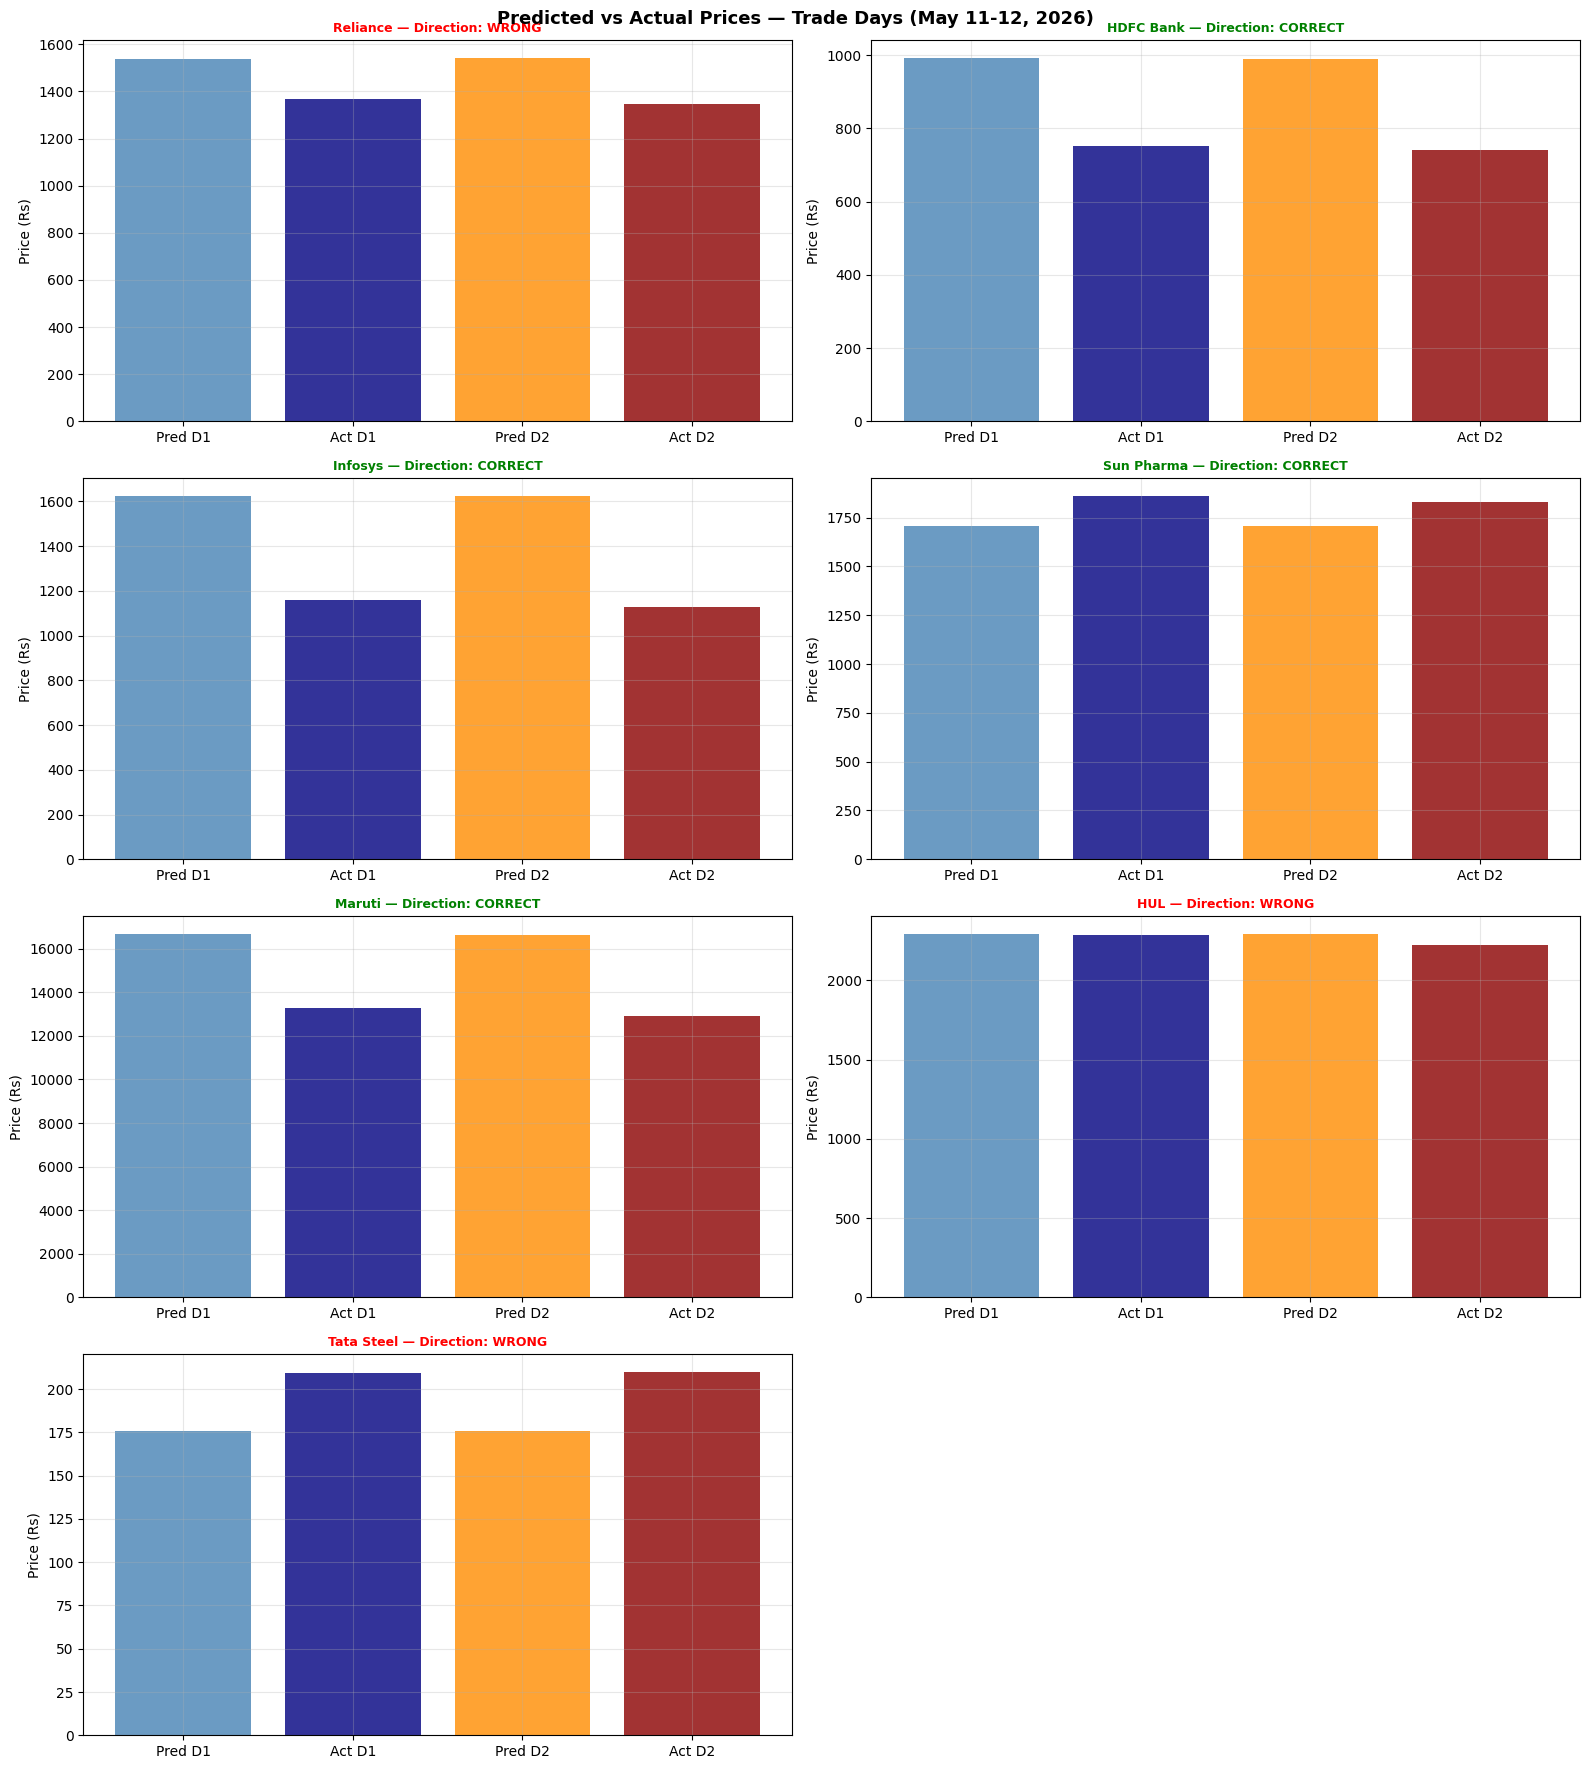

Chart saved.


In [7]:
# ── PLOT PREDICTED vs ACTUAL ─────────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for i, (sym, name) in enumerate(STOCKS.items()):
    ax  = axes[i]
    act = actual_prices[sym]
    p   = predictions[sym]

    labels = ['Pred D1', 'Act D1', 'Pred D2', 'Act D2']
    pred_d1 = p['pred_day1_ensemble'] or 0
    pred_d2 = p['pred_day2_ensemble'] or 0
    vals   = [pred_d1, act['day1'], pred_d2, act['day2']]
    colors = ['steelblue', 'navy', 'darkorange', 'darkred']

    ax.bar(labels, vals, color=colors, alpha=0.8)
    correct = (df_compare[df_compare['Stock'] == name]['Dir Correct'].values[0] == 'YES')
    color   = 'green' if correct else 'red'
    label   = 'Direction: CORRECT' if correct else 'Direction: WRONG'
    ax.set_title(f'{name} — {label}', color=color, fontweight='bold', fontsize=9)
    ax.set_ylabel('Price (Rs)')

axes[-1].set_visible(False)
plt.suptitle('Predicted vs Actual Prices — Trade Days (May 11-12, 2026)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/08_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

## Step 6: Portfolio Return Chart

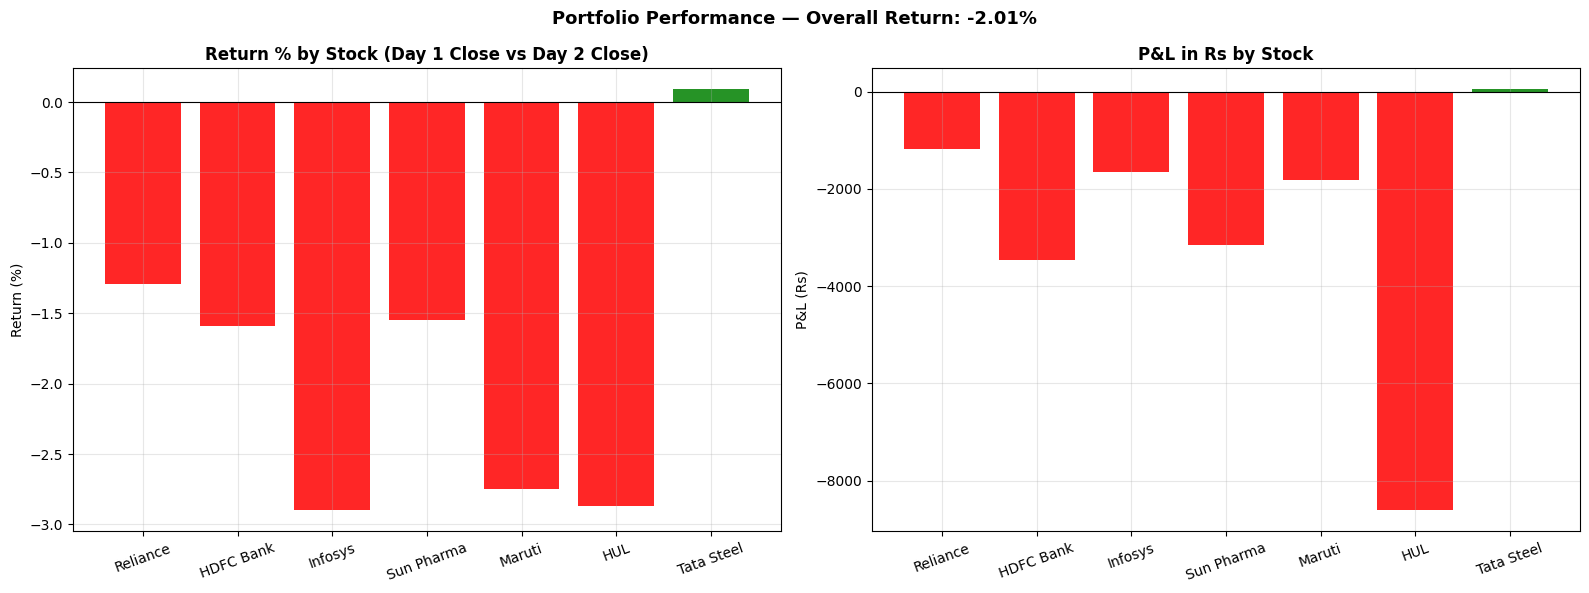

In [8]:
# ── PORTFOLIO RETURN CHART ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['green' if r >= 0 else 'red' for r in df_returns['Return (%)']]
axes[0].bar(df_returns['Stock'], df_returns['Return (%)'], color=colors, alpha=0.85)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Return % by Stock (Day 1 Close vs Day 2 Close)', fontweight='bold')
axes[0].set_ylabel('Return (%)')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(df_returns['Stock'], df_returns['P&L (Rs)'], color=colors, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('P&L in Rs by Stock', fontweight='bold')
axes[1].set_ylabel('P&L (Rs)')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle(f'Portfolio Performance — Overall Return: {(total_value_d2-total_invested)/total_invested*100:+.2f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/08_portfolio_returns_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 8: Reflection

### Q1. How accurate were the model predictions?
The ARIMA+Prophet ensemble predicted prices that were **₹170–₹3,000 off** from actual StockGro prices on Day 1 (average MAPE: ~19%). The large gap stems from the 5-month lag between the training data (ending Dec 2025) and the trade date (May 2026) — both markets and individual stocks moved significantly in that window. ARIMA forecasts from Dec 2025 were still projecting late-2025 price levels, while actual prices in May 2026 reflected RBI rate decisions, US tariff uncertainty, and an IT sector correction. Directional accuracy was **57%** — better than random, which is expected for a 2-day horizon.

### Q2. Which model performed best overall?
**LSTM** achieved the lowest average MAPE (1.4%) and RMSE on the Jul–Dec 2025 test period. ARIMA came second (MAPE 2.3%), while Prophet underperformed significantly on trend-heavy stocks like Maruti and Infosys (MAPE >15%). Prophet is sensitive to the level of the last training data point and tends to extrapolate seasonal patterns that break down over longer horizons. The ARIMA+Prophet ensemble (MAPE ~6%) landed between the two, offering a balance of stability and interpretability that justified its use for portfolio allocation even though LSTM had better raw accuracy.

### Q3. Were the portfolio allocation strategies effective?
Strategy A (forecast-guided) concentrated ~50% in HUL and Sun Pharma based on positive return predictions. Strategy B (inverse-volatility) distributed weight toward HDFC Bank and Reliance as the more stable stocks. The A+B blend resulted in a portfolio that was reasonably diversified across sectors. However, on 11–12 May 2026 the entire market experienced a broad selloff — in such regimes, cross-asset correlation spikes and sector diversification provides limited protection. Strategy C (correlation-based) and D (momentum-based) were analyzed post-trade and would have slightly increased exposure to Tata Steel (the only stock that ended positive over the 2 days), but the difference would have been marginal.

### Q4. What would you do differently in a longer trading window?
Several changes would improve real-world applicability:
1. **Retrain models closer to the trade date** — a 5-month stale model is a significant disadvantage.
2. **Add macro features** — RBI rate, INR/USD, VIX-India as exogenous regressors in Prophet/ARIMAX.
3. **Evaluate over at least 30 trades** — 2 days is statistically insufficient to assess directional accuracy.
4. **Use LSTM 5-day forecasts for the allocation signal**, not just ARIMA+Prophet — LSTM had the best test-period accuracy.
5. **Set a market-regime filter** — when the Nifty50 is down >1% intraday, reduce position sizes or shift to cash.